## Sanity Check dos jogos de cada temporada e de todos os times presentes de cada competição

Importa o cliente de `gradient_client.py`.  
A autenticação é lida automaticamente do arquivo `.env` (`BEARER_TOKEN`).

In [7]:
import pandas as pd
import sys
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

sys.path.append(str(Path().resolve().parent.parent))
from src.gradient_client import GradientSportsClient

pd.set_option('display.max_columns', None)

### Status da requisição

In [8]:
client = GradientSportsClient()

# health check
client.get_status()

{'data': {'status': 'ok'}}

### Competições

In [9]:
df_competitions = pd.read_csv(str(Path().resolve().parent.parent / "data" / "competitions.csv"))
df_competitions

,season,competitionId,competitionName
0,2020-2021,1,Premier League
1,2021-2022,1,Premier League
2,2022-2023,1,Premier League
3,2023-2024,1,Premier League
4,2024-2025,1,Premier League
5,2025-2026,1,Premier League
6,2026-2027,1,Premier League
7,2023,42,Brasileiro Série A
8,2024,42,Brasileiro Série A
9,2025,42,Brasileiro Série A


- Existem dados de duas competições, Premier League e Brasileiro Série A.
- Dentre essas competições, existem dados de 6 temporadas da Premier League e 4 temporadas do Brasileiro Série A.
- Não parecem haver incosistências nos dados de competições.

### Times

In [10]:
# teams the account can access
df_teams = pd.read_csv(str(Path().resolve().parent.parent / "data" / "teams.csv"))
df_teams

,teamId,teamName,competitionId,competitionName
0,1.0,AFC Bournemouth,1,Premier League
1,20.0,Wolverhampton Wanderers,1,Premier League
2,221.0,Nottingham Forest,1,Premier League
3,335.0,Sunderland AFC,1,Premier League
4,10.0,Liverpool,1,Premier League
...,...,...,...,...
56,437.0,Fortaleza,42,Brasileiro Série A
57,514.0,Cruzeiro,42,Brasileiro Série A
58,864.0,Chapecoense,42,Brasileiro Série A
59,517.0,Bahia,42,Brasileiro Série A


In [11]:
df_teams.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   teamId           59 non-null     float64
 1   teamName         59 non-null     str    
 2   competitionId    61 non-null     int64  
 3   competitionName  61 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 3.7 KB


In [12]:
df_teams.duplicated('teamId').sum()

np.int64(1)

- O dataset de times possui duas colunas com ids dos times nulas e uma duplicata.

In [13]:
df_teams[df_teams.duplicated('teamId', keep=False)]

,teamId,teamName,competitionId,competitionName
18,NaN,NaN,1,Premier League
55,NaN,NaN,42,Brasileiro Série A


- As duas duplicatas são NaN em competições diferentes, ao mesmo tempo que é o gerador de duplicata. Ambos devem ser removidos.

In [14]:
df_teams = df_teams[df_teams['teamId'].notna()].reset_index(drop=True)

In [15]:
df_teams.to_csv(str(Path().resolve().parent.parent / "data" / "teams.csv"), index=False)

In [16]:
df_teams['competitionName'].value_counts()

competitionName
Premier League        30
Brasileiro Série A    29
Name: count, dtype: int64

- Entre as temporadas, existem dados de 28 times da Premier League e 29 do Brasileirão.

### Jogos

In [17]:
# all games — or filter by season / competition / team
# as_dataframe=True → one row per game, nested dicts dot-expanded
games = pd.read_csv(str(Path().resolve().parent.parent / "data" / "games.csv"))
games

,gameId,date,season,teamExtraTimeStartSide,teamStartSide,venueType,teamId,teamName,competitionId,competitionName,opponentTeamId,opponentTeamName,stadiumName,stadiumLength,stadiumWidth
0,1372,2022-03-20,2021-2022,Right,Right,TEAM_HOME,17,Tottenham Hotspur,1,Premier League,19,West Ham,Tottenham Hotspur Stadium,105.0,68.0
1,32348,2025-05-11,2024-2025,Left,Left,OPPONENT_HOME,2,Arsenal,1,Premier League,10,Liverpool,Anfield,101.0,68.0
2,24128,2024-06-30,2024,Left,Left,OPPONENT_HOME,514,Cruzeiro,42,Brasileiro Série A,435,Flamengo,Maracanã,105.0,68.0
3,423,2021-03-04,2020-2021,Left,Left,OPPONENT_HOME,6,Chelsea,1,Premier League,10,Liverpool,Anfield,101.0,68.0
4,51567,2026-02-12,2026,Left,Left,OPPONENT_HOME,430,Botafogo,42,Brasileiro Série A,436,Fluminense FC,Maracanã,105.0,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3656,40894,2025-08-30,2025-2026,Right,Left,TEAM_HOME,55,Leeds United,1,Premier League,13,Newcastle United,Elland Road,105.0,68.0
3657,349,2021-01-27,2020-2021,Right,Left,TEAM_HOME,4,Brighton & Hove Albion,1,Premier League,54,Fulham,American Express Stadium,105.0,68.0
3658,4539,2022-10-16,2022-2023,Left,Right,OPPONENT_HOME,2,Arsenal,1,Premier League,55,Leeds United,Elland Road,105.0,68.0
3659,4686,2023-03-04,2022-2023,Left,Right,OPPONENT_HOME,1,AFC Bournemouth,1,Premier League,2,Arsenal,Emirates Stadium,105.0,68.0


In [18]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 3661 entries, 0 to 3660
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gameId                  3661 non-null   int64  
 1   date                    3661 non-null   str    
 2   season                  3661 non-null   str    
 3   teamExtraTimeStartSide  3661 non-null   str    
 4   teamStartSide           3661 non-null   str    
 5   venueType               3661 non-null   str    
 6   teamId                  3661 non-null   int64  
 7   teamName                3661 non-null   str    
 8   competitionId           3661 non-null   int64  
 9   competitionName         3661 non-null   str    
 10  opponentTeamId          3661 non-null   int64  
 11  opponentTeamName        3661 non-null   str    
 12  stadiumName             3661 non-null   str    
 13  stadiumLength           3661 non-null   float64
 14  stadiumWidth            3661 non-null   float64
dty

In [19]:
games.duplicated('gameId').sum()

np.int64(0)

- O conjunto de dados de jogos não possui linhas duplicadas ou dados ausentes.

In [20]:
games['competitionName'].value_counts()

competitionName
Premier League        2295
Brasileiro Série A    1366
Name: count, dtype: int64

- Existem 2205 partidas da Premier League e 1207 do Brasileirão.

In [21]:
games[['competitionName', 'season']].value_counts().sort_index()

competitionName     season   
Brasileiro Série A  2023         381
                    2024         376
                    2025         379
                    2026         230
Premier League      2020-2021    378
                    2021-2022    377
                    2022-2023    380
                    2023-2024    381
                    2024-2025    380
                    2025-2026    380
                    2026-2027     19
Name: count, dtype: int64

- Nota-se que os dados não apresentam redundâncias (exemplo: Time A x Time B / Time B x Time A) e completam 380 partidas, no máximo.
- Na temporada 2023-2024 há um dado a mais, indicando uma incosistência nos dados.
- Existem temporadas faltando dados, exceto 2025-2026 (Premier League) e 2026 (Brasileirão) que ainda estão em andamento.

In [23]:
games[['stadiumLength', 'stadiumWidth']].value_counts()

stadiumLength  stadiumWidth
105.0          68.0            2872
101.0          68.0             268
103.0          67.5             115
100.0          65.0              97
100.5          68.0              95
105.0          69.0              55
110.0          68.0              49
109.0          72.0              29
105.0          67.5              21
102.0          64.0              20
100.0          66.0              19
104.0          68.0              19
110.0          75.0               1
               70.0               1
Name: count, dtype: int64

- Nota-se que existem algumas variações de tamanho (Comprimento x Largura) de estádio, mas o tamanho padrão possui a maior volumetria.

In [24]:
def expand_teams(df):
    df_home = df[["season", "competitionName", "teamName"]].rename(
        columns={"teamName": "team"}
    )

    df_away = df[["season", "competitionName", "opponentTeamName"]].rename(
        columns={"opponentTeamName": "team"}
    )

    return pd.concat([df_home, df_away], ignore_index=True)


games_expanded = expand_teams(games)


# 1. FILTROS + AGREGAÇÃO
df_pl = (
    games_expanded[games_expanded["competitionName"] == "Premier League"]
    .groupby(["season", "team"])
    .size()
    .reset_index(name="matches")
)

df_br = (
    games_expanded[games_expanded["competitionName"] == "Brasileiro Série A"]
    .groupby(["season", "team"])
    .size()
    .reset_index(name="matches")
)

# 2. REMOVER ÚLTIMA TEMPORADA
df_pl = df_pl[df_pl["season"] != df_pl["season"].max()]
df_br = df_br[df_br["season"] != df_br["season"].max()]

# 3. PIVOT
df_pl_pivot = df_pl.pivot(index="team", columns="season", values="matches")
df_br_pivot = df_br.pivot(index="team", columns="season", values="matches")

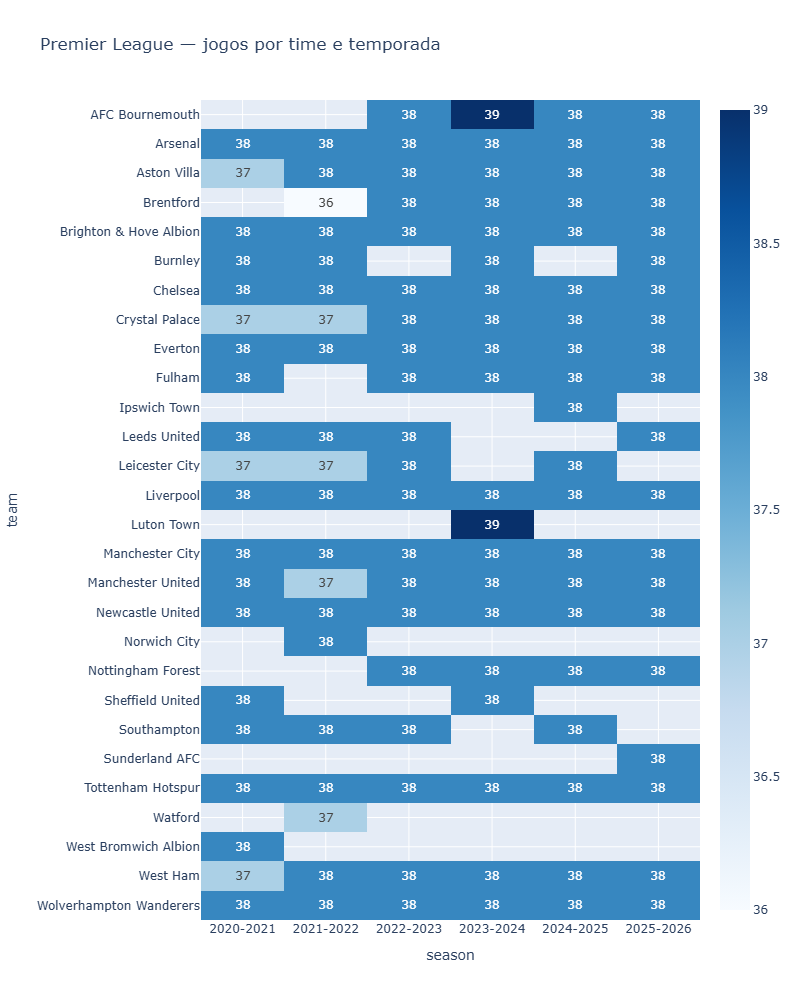

In [25]:
fig_pl = px.imshow(
    df_pl_pivot,
    aspect="auto",
    text_auto=True,
    color_continuous_scale="Blues",
    title="Premier League — jogos por time e temporada",
)

fig_pl.update_layout(
    height=1000,
    width=800
)

fig_pl.show('png')

- Pode-se notar que, conforme as temporadas disponiveis, a distribuição de dados disponíveis dos times aparenta ter completude nos dados, salvo exceções.
- Alguns momentos há dados faltantes, como casos com 36 ou 37 jogos. 
- Curiosamente, o time AFC Bournemouth e Luton Town tiveram uma partida a mais na temporada 2023-2024, ou seja, uma inconsistência nos dados.
- Não foi incluída a última temporada (2025-2026) pois os dados seguem em atualização devido a temporada não ter sido concluída.

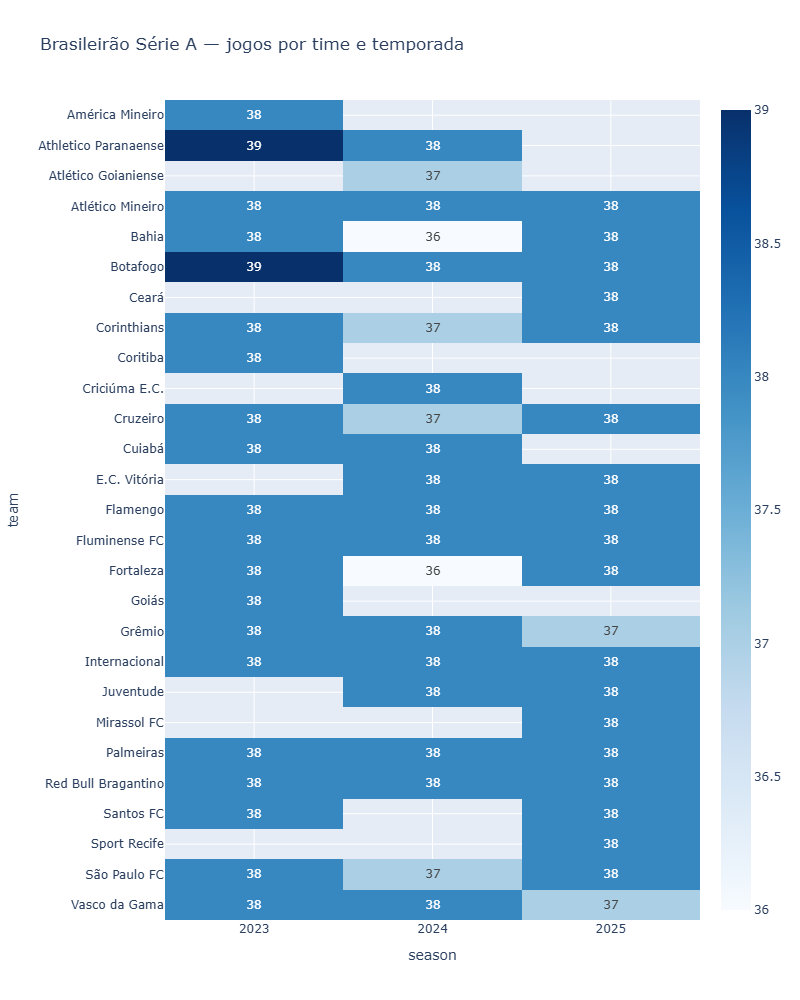

In [26]:
fig_br = px.imshow(
    df_br_pivot,
    aspect="auto",
    text_auto=True,
    color_continuous_scale="Blues",
    title="Brasileirão Série A — jogos por time e temporada"
)

fig_br.update_layout(
    height=1000,
    width=800
)

fig_br.show('png')

- Assim como os dados da Premier League, há times com uma ou duas partidas a menos de dados. Porém, de forma geral, sugere-se haver uma completude de registros dos jogos.
- Também nota-se que o Botafogo em 2023 possui um registro a mais de partida, apontando uma incosistência nos dados também.
- Não foi incluída a última temporada (2025-2026) pois os dados seguem em atualização devido a temporada não ter sido concluída.

In [27]:
games.loc[(games['season'] == '2023-2024') & 
          ((games['teamName'] == 'AFC Bournemouth') | 
           (games['opponentTeamName'] == 'AFC Bournemouth')), ['teamName', 'opponentTeamName']].melt().value_counts('value')

value
AFC Bournemouth            39
Luton Town                  3
Wolverhampton Wanderers     2
Everton                     2
Nottingham Forest           2
Arsenal                     2
Burnley                     2
Sheffield United            2
Tottenham Hotspur           2
Manchester United           2
Manchester City             2
Newcastle United            2
Liverpool                   2
Aston Villa                 2
Brentford                   2
Crystal Palace              2
Fulham                      2
Brighton & Hove Albion      2
West Ham                    2
Chelsea                     2
Name: count, dtype: int64

In [28]:
games.loc[(games['season'] == '2023-2024') & 
          (((games['teamName'] == 'AFC Bournemouth') | 
           (games['opponentTeamName'] == 'AFC Bournemouth')) &
          ((games['teamName'] == 'Luton Town') | 
           (games['opponentTeamName'] == 'Luton Town')))]

,gameId,date,season,teamExtraTimeStartSide,teamStartSide,venueType,teamId,teamName,competitionId,competitionName,opponentTeamId,opponentTeamName,stadiumName,stadiumLength,stadiumWidth
1439,20480,2024-03-13,2023-2024,Right,Right,TEAM_HOME,1,AFC Bournemouth,1,Premier League,218,Luton Town,Vitality Stadium,105.0,68.0
2786,13496,2023-12-16,2023-2024,Right,Right,TEAM_HOME,1,AFC Bournemouth,1,Premier League,218,Luton Town,Vitality Stadium,105.0,68.0
3444,13650,2024-04-06,2023-2024,Left,Left,OPPONENT_HOME,1,AFC Bournemouth,1,Premier League,218,Luton Town,Kenilworth Road,100.0,66.0


- Nota-se que um dos registros está incosistente pela data e gerou uma duplicata. A data '2023-12-16' está incorreta, já que esse jogo foi em '2024-03-13'.
- Como o registro a mais envolve os dois times com um jogo a mais, remover essa duplicata iria corrigir o jogo a mais tanto do AFC Bournemouth quanto do Luton Town.

In [29]:
# Remoção da incosistência
games.drop(games[games['gameId'] == 13496].index, axis=0, inplace=True)

In [30]:
games.loc[(games['season'] == '2023') & 
          ((games['teamName'] == 'Botafogo') | 
           (games['opponentTeamName'] == 'Botafogo')), ['teamName', 'opponentTeamName']].melt().value_counts('value')

value
Botafogo                39
Athletico Paranaense     3
Bahia                    2
Atlético Mineiro         2
América Mineiro          2
Flamengo                 2
Goiás                    2
Corinthians              2
Red Bull Bragantino      2
Fortaleza                2
Vasco da Gama            2
Grêmio                   2
Cruzeiro                 2
Cuiabá                   2
Internacional            2
Coritiba                 2
Palmeiras                2
Santos FC                2
São Paulo FC             2
Fluminense FC            2
Name: count, dtype: int64

In [31]:
games.loc[(games['season'] == '2023') & 
          (((games['teamName'] == 'Botafogo') | 
           (games['opponentTeamName'] == 'Botafogo')) &
          ((games['teamName'] == 'Athletico Paranaense') | 
           (games['opponentTeamName'] == 'Athletico Paranaense')))]

,gameId,date,season,teamExtraTimeStartSide,teamStartSide,venueType,teamId,teamName,competitionId,competitionName,opponentTeamId,opponentTeamName,stadiumName,stadiumLength,stadiumWidth
533,20421,2023-10-22,2023,Left,Right,OPPONENT_HOME,426,Athletico Paranaense,42,Brasileiro Série A,430,Botafogo,Estádio Olímpico Nilton Santos,105.0,68.0
2792,12578,2023-06-03,2023,Right,Right,TEAM_HOME,426,Athletico Paranaense,42,Brasileiro Série A,430,Botafogo,Arena da Baixada,105.0,68.0
3451,12766,2023-10-22,2023,Left,Right,OPPONENT_HOME,426,Athletico Paranaense,42,Brasileiro Série A,430,Botafogo,Estádio Olímpico Nilton Santos,105.0,68.0


- Nota-se que um dos registros está incosistente pelo id e gerou uma duplicata. Seria necessário remover um dos dois registros para corrigir a incosistência.